How did the 2026 Strait of Hormuz closure change crude oil flows and import composition for the US and China relative to a fixed pre-crisis baseline, 
and how differently did the shock pass through to retail fuel prices in each country?

In [76]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd().parent
FIGS_OUT = 'C:\\Users\\henry\\Desktop\\Programming and Networking\\Personal Projects\\Data Science Projects\\Oil Supply and Demand Analysis\\figures'

# Chronology (docs/chronology_table.xlsx):
#   2026-02-27  closure
#   2026-04-08  partial reopening after Pakistan-brokered ceasefire
#   2026-04-18  re-closure, citing US naval blockade
#   2026-06-17  reopening under US-Iran MOU
#   2026-07     breakdown, effectively closed again


Run-up detected from 2019-01-03 (threshold 48 calls/day)

     baseline      start        end  days  calls_before  calls_after  calls_ratio  vol_ratio
crisis_length 2025-10-04 2026-02-26   146          41.9         4.22         9.94       9.88
    pre_spike 2025-10-04 2019-01-02     0           NaN         4.22          NaN        NaN
   fixed_year 2025-02-27 2026-02-26   365          50.8         4.22        12.04      11.86


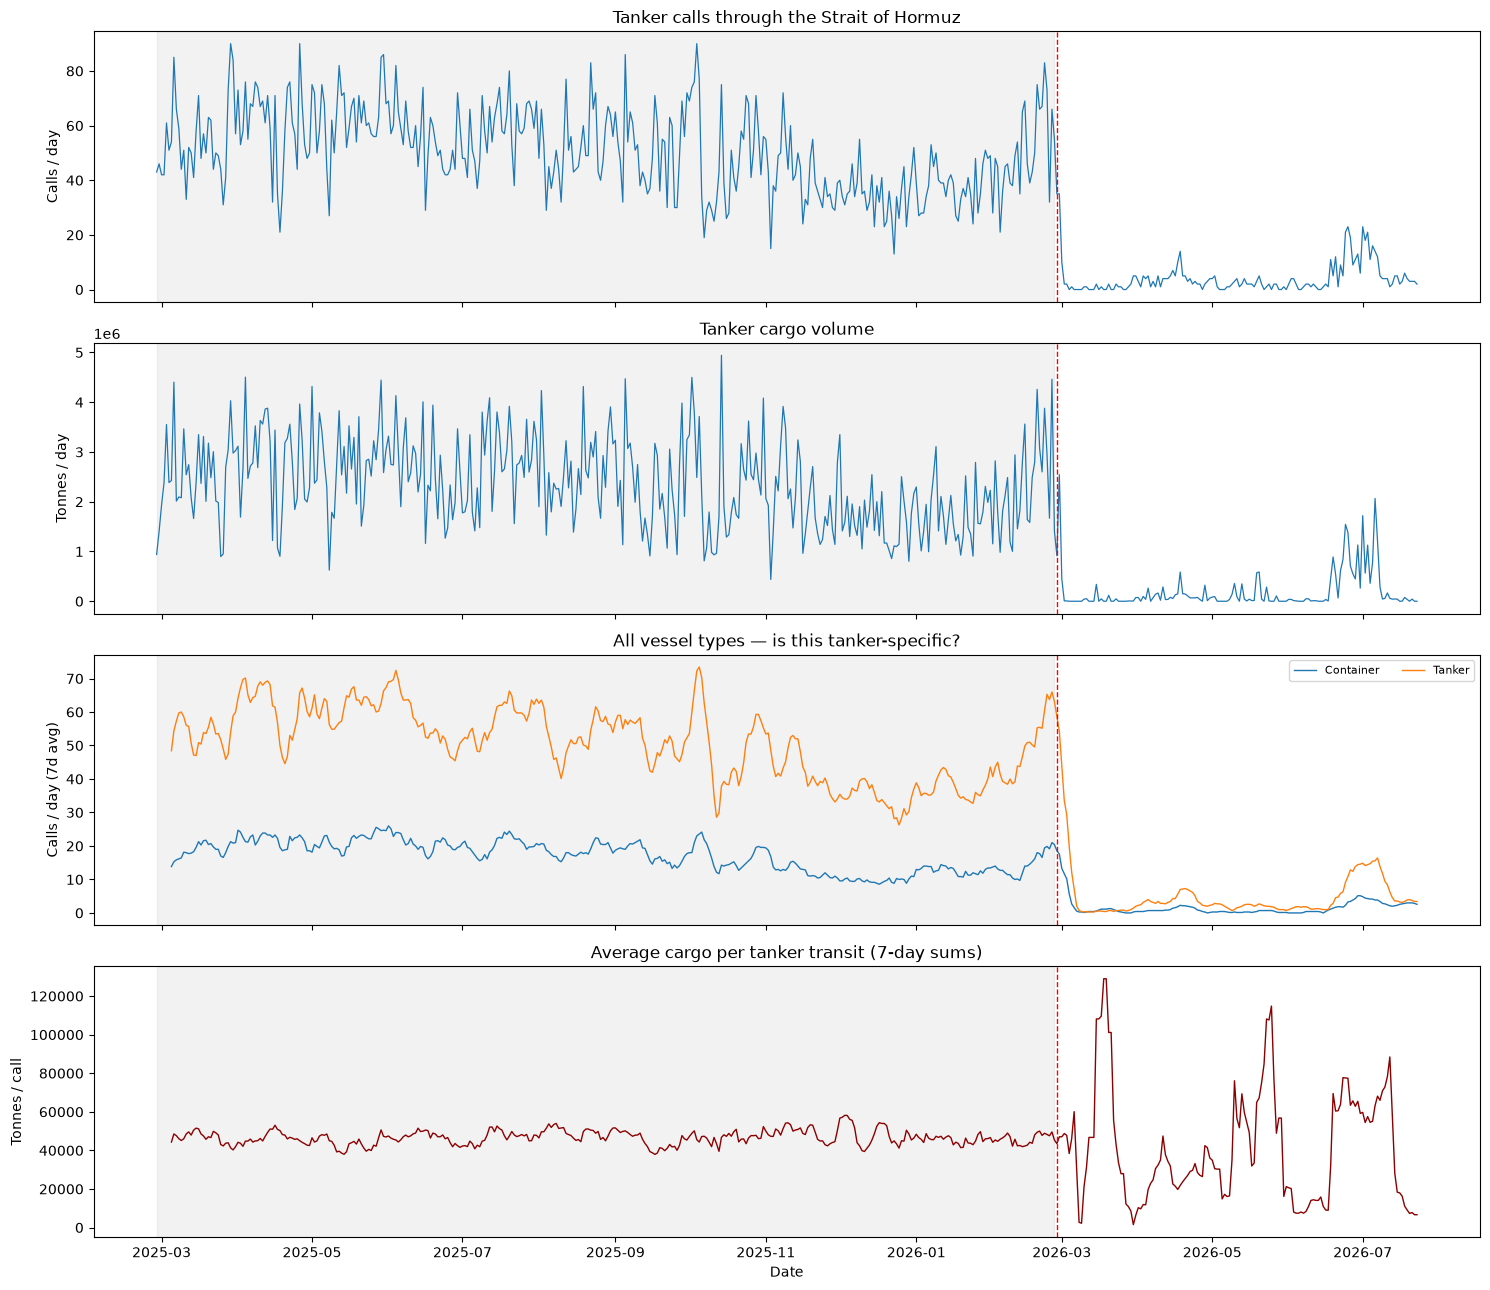

In [ ]:
# did the disruption happen and how big? (hormuz-transits-daily)
TRANSITS_CSV = ROOT_DIR / 'data' / 'processed' / 'hormuz-transits-daily.csv'
transits_df = pd.read_csv(TRANSITS_CSV, parse_dates=['DateTime'])

strait_closure = pd.to_datetime('2026-02-27')
end = transits_df['DateTime'].max()
crisis_days = (end - strait_closure).days
crisis = transits_df[transits_df['DateTime'] >= strait_closure]

# Where does the pre-closure run-up begin?
winter = transits_df[
    (transits_df['DateTime'] >= strait_closure - pd.DateOffset(months=3)) &
    (transits_df['DateTime'] <  strait_closure - pd.DateOffset(weeks=3))
]
spike_threshold = winter['Tanker_calls'].quantile(0.90)
run_up = transits_df[
    (transits_df['DateTime'] < strait_closure) &
    (transits_df['Tanker_calls'] > spike_threshold)
]
spike_start = run_up['DateTime'].min()

# Three baseline definitions 
baselines = {
    'crisis_length': (strait_closure - pd.Timedelta(days=crisis_days),
                      strait_closure - pd.Timedelta(days=1)),
    'pre_spike':     (strait_closure - pd.Timedelta(days=crisis_days),
                      spike_start - pd.Timedelta(days=1)),
    'fixed_year':    (strait_closure - pd.DateOffset(years=1),
                      strait_closure - pd.Timedelta(days=1)),
}
rows = []
for label, (b_start, b_end) in baselines.items():
    base = transits_df[
        (transits_df['DateTime'] >= b_start) & (transits_df['DateTime'] <= b_end)
    ]
    rows.append({
        'baseline': label,
        'start': b_start.date(),
        'end': b_end.date(),
        'days': len(base),
        'calls_before': base['Tanker_calls'].mean(),
        'calls_after': crisis['Tanker_calls'].mean(),
        'calls_ratio': base['Tanker_calls'].mean() / crisis['Tanker_calls'].mean(),
        'vol_ratio': base['Tanker_volume'].mean() / crisis['Tanker_volume'].mean(),
    })
sensitivity = pd.DataFrame(rows).round(2)
print(f"Run-up detected from {spike_start.date()} "
      f"(threshold {spike_threshold:.0f} calls/day)\n")
print(sensitivity.to_string(index=False))

# Plot 
plot_start = baselines['fixed_year'][0]
window = transits_df[
    (transits_df['DateTime'] >= plot_start) & (transits_df['DateTime'] <= end)
].copy()

# 7-day sums
roll_vol = window['Tanker_volume'].rolling(7).sum()
roll_calls = window['Tanker_calls'].rolling(7).sum()
window['vol_per_call'] = (roll_vol / roll_calls).replace([np.inf, -np.inf], np.nan)
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
ax1, ax2, ax3, ax4 = axes
ax1.plot(window['DateTime'], window['Tanker_calls'], linewidth=0.9)
ax1.set_ylabel("Calls / day")
ax1.set_title("Tanker calls through the Strait of Hormuz")
ax2.plot(window['DateTime'], window['Tanker_volume'], linewidth=0.9)
ax2.set_ylabel("Tonnes / day")
ax2.set_title("Tanker cargo volume")

# Is the collapse tanker-specific, or did all shipping stop?
for col in ['Container_calls', 'Dry Bulk_calls', 'General Cargo_calls', 'Tanker_calls']:
    if col in window.columns:
        ax3.plot(window['DateTime'], window[col].rolling(7).mean(),
                 linewidth=1, label=col.replace('_calls', ''))
ax3.set_ylabel("Calls / day (7d avg)")
ax3.set_title("All vessel types — is this tanker-specific?")
ax3.legend(fontsize=8, ncol=4)

# Measurement-error check
ax4.plot(window['DateTime'], window['vol_per_call'], linewidth=1, color='darkred')
ax4.set_ylabel("Tonnes / call")
ax4.set_xlabel("Date")
ax4.set_title("Average cargo per tanker transit (7-day sums)")
for ax in axes:
    ax.axvline(strait_closure, color='red', linestyle='--', linewidth=1)
    ax.axvspan(*baselines['fixed_year'], color='grey', alpha=0.10)
fig.tight_layout()
fig.savefig(FIGS_OUT + "//hormuz-disruption-overview.png", dpi=150)
plt.show()

In [ ]:
# How did flows change? ()